In this project, I will analyze historical stock performance of Apple over the past year. The goal of the analysis is to understand how the stock's price, volume, and volatility have behaved over time to identify patterns that may inform investment decisions.

**Step 1**\
***a.*** To begin, I will install the 'yfinance' library, which will give me access to Yahoo Finance's stock data.

In [1]:
!pip install yfinance

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels


***b.*** Now, I will import the necessary libraries for my analysis. (yfinance, pandas, matplotlib, seaborn) 

In [2]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

**Step 2**\
***a.*** Using the yfinance library, I will download a year of Apple (AAPL) stock data from Yahoo Finance into a dataframe. The dataframe will include Open, High, Low, Close, and Volume columns for each trading day (one row is one trading day).

In [3]:
aapl_df = yf.download('AAPL', start='2024-09-09', end='2025-09-09')
aapl_df.head(10)

/tmp/ipykernel_566/1407292742.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  aapl_df = yf.download('AAPL', start='2024-09-09', end='2025-09-09')
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2024-09-09,219.468353,219.826005,215.295765,219.378944,67180000
2024-09-10,218.673553,220.034608,215.315607,217.491317,51591000
2024-09-11,221.206924,221.634111,216.468049,220.014759,44587100
2024-09-12,221.316193,222.091101,218.385448,221.047950,37455600
2024-09-13,221.047943,222.577886,220.461797,222.120897,36766600
2024-09-16,214.908310,215.802431,212.523963,215.126860,59357400
2024-09-17,215.375229,215.484512,213.100180,214.342023,45519300
2024-09-18,219.249771,221.256593,216.120319,216.130263,59894900


***b.*** I will check the dataframe for any missing values and get more basic info about the data.

In [4]:
aapl_df.isnull().sum()

Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64

In [5]:
aapl_df.duplicated().sum()

0

In [6]:
aapl_df.describe()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,250.000000,250.000000,250.000000,250.000000,2.500000e+02
mean,221.571535,223.768304,219.015301,221.240211,5.397740e+07
std,16.145500,15.631204,16.361151,16.107618,2.774047e+07
min,171.671799,189.514035,168.475737,171.203815,2.323470e+07
25%,209.375347,211.360845,207.183796,209.335471,3.951048e+07
50%,224.047081,225.552869,221.678817,223.396057,4.686590e+07
75%,232.279179,234.517085,229.677278,232.217281,5.681858e+07
max,257.612732,258.686881,256.230300,256.787255,3.186799e+08


In [7]:
aapl_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 250 entries, 2024-09-09 to 2025-09-08
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   250 non-null    float64
 1   (High, AAPL)    250 non-null    float64
 2   (Low, AAPL)     250 non-null    float64
 3   (Open, AAPL)    250 non-null    float64
 4   (Volume, AAPL)  250 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 11.7 KB


In [8]:
aapl_df.shape

(250, 5)

There are no missing values, and nothing that looks out of place. I will save the dataframe as a csv, just in case a backup is needed.

In [9]:
aapl_df.to_csv('AAPL_stock_data.csv')

**Step 4**\
Before beginning, I will plot the closing price of the stock. It will show me an overview of the stock price movement over the year.

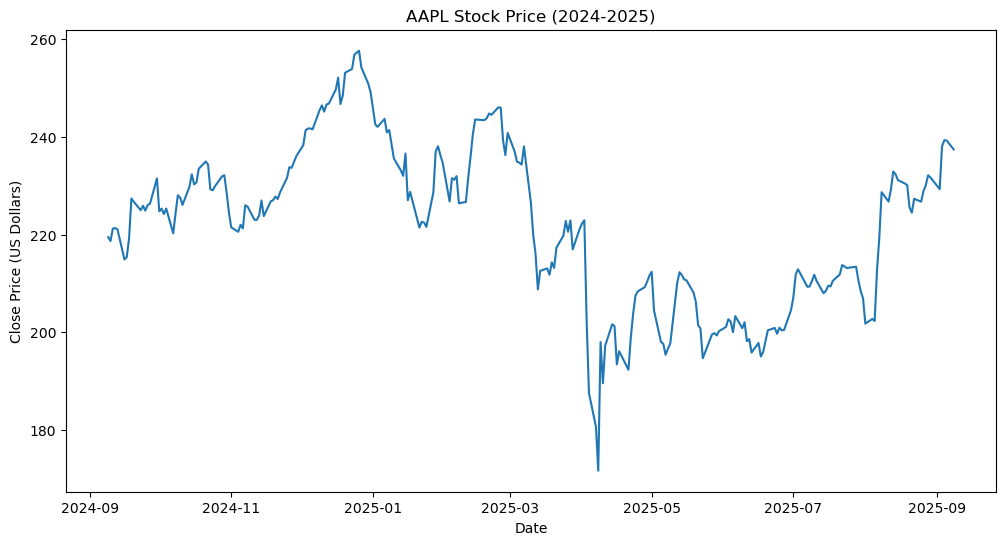

In [10]:
plt.figure(figsize=(12,6))
plt.plot(aapl_df['Close'])
plt.title('AAPL Stock Price (2024-2025)')
plt.xlabel('Date')
plt.ylabel('Close Price (US Dollars)')
plt.show()

*Findings*: Apple's closing price had a generally upward trend over the 2024-2025 period. There was a large dip in the beginning of 2025. Upon some research, this dip was likely caused by the trade wars at the time and an announcement from management about a delay in the new AI-powered Siri (refernece:https://finance.yahoo.com/news/why-apple-fell-18-1-140741744.html). After about May, the stock began recovering and ended the period at a higher price than it began. Although Apple experienced some short-term volatility, its overall performance for the year remained strong.

**Step 5**\
The first thing I'll do is calculate the daily return of the stock and analyze it by printing the summary statistics and plotting it. Daily return measures the percentage change in the stock's closing price from one trading day to the next. In other words, it shows how much the stock's price increased/decreased each day, in percentage. This will be used as a base for my further analysis.

In [11]:
aapl_df['Daily_return'] = aapl_df['Close'].pct_change()

In [12]:
aapl_df.head()

Price,Close,High,Low,Open,Volume,Daily_return
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,
Date,,,,,,
2024-09-09,219.468353,219.826005,215.295765,219.378944,67180000,NaN
2024-09-10,218.673553,220.034608,215.315607,217.491317,51591000,-0.003621
2024-09-11,221.206924,221.634111,216.468049,220.014759,44587100,0.011585
2024-09-12,221.316193,222.091101,218.385448,221.047950,37455600,0.000494
2024-09-13,221.047943,222.577886,220.461797,222.120897,36766600,-0.001212


In [13]:
aapl_df.tail()

Price,Close,High,Low,Open,Volume,Daily_return
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,
Date,,,,,,
2025-09-02,229.282990,230.410845,226.538221,228.813882,44075600,-0.010425
2025-09-03,238.016342,238.395624,233.914160,236.758745,66427800,0.038090
2025-09-04,239.323853,239.443619,236.289642,237.996381,47549400,0.005493
2025-09-05,239.234009,240.860913,238.036295,239.543417,54870400,-0.000375
2025-09-08,237.427460,239.693130,235.890381,238.844756,48999500,-0.007551


In [14]:
aapl_df['Daily_return'].dropna()

Date
2024-09-10   -0.003621
2024-09-11    0.011585
2024-09-12    0.000494
2024-09-13   -0.001212
2024-09-16   -0.027775
                ...   
2025-09-02   -0.010425
2025-09-03    0.038090
2025-09-04    0.005493
2025-09-05   -0.000375
2025-09-08   -0.007551
Name: Daily_return, Length: 249, dtype: float64

In [15]:
aapl_df.describe()

Price,Close,High,Low,Open,Volume,Daily_return
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,
count,250.000000,250.000000,250.000000,250.000000,2.500000e+02,249.000000
mean,221.571535,223.768304,219.015301,221.240211,5.397740e+07,0.000520
std,16.145500,15.631204,16.361151,16.107618,2.774047e+07,0.020350
min,171.671799,189.514035,168.475737,171.203815,2.323470e+07,-0.092456
25%,209.375347,211.360845,207.183796,209.335471,3.951048e+07,-0.007058
50%,224.047081,225.552869,221.678817,223.396057,4.686590e+07,0.001140
75%,232.279179,234.517085,229.677278,232.217281,5.681858e+07,0.009404
max,257.612732,258.686881,256.230300,256.787255,3.186799e+08,0.153288


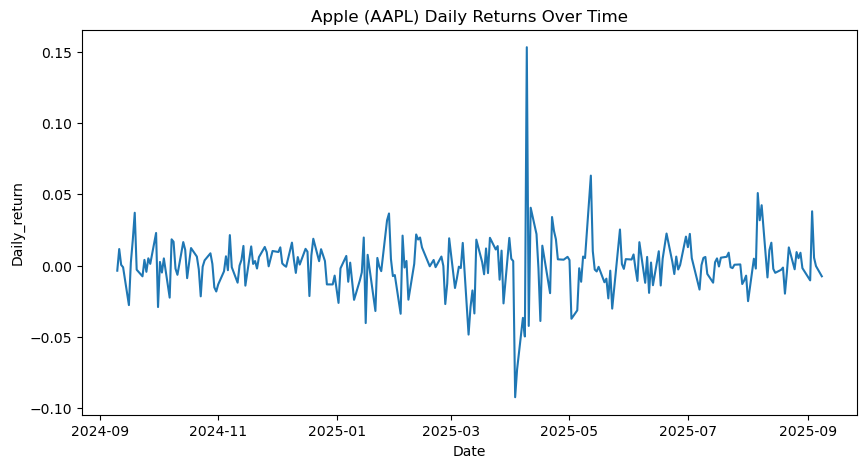

In [16]:
plt.figure(figsize=(10,5))
sns.lineplot(x='Date', y='Daily_return', data=aapl_df)
plt.title('Apple (AAPL) Daily Returns Over Time')
plt.xlabel('Date')
plt.ylabel('Daily_return')
plt.show()

*Findings:* Apple stock's daily returns stayed within a +/-2% range for the year. This tells us that the stock has a relatively stable performance. There are a few spikes, but those could be normal responses to events such as earning reports or company announcements. 

**Step 6**\
I will calculate overall volatility and rolling volatility (and plot the rolling one). Overall volatility will summarize the average daily risk of the stock over the year. Rolling volatility will show how daily price fluctuations change over time, helping identify periods of higher or lower volatility.

In [17]:
volatility = aapl_df['Daily_return'].std()
print('Overall Volatility:', round(volatility, 4))

Overall Volatility: 0.0204


*Findings:* The overall volatility of 0.0204, indicates that Apple's daily returns averaged 2.04% over the year period of 2024-2025. This shows that Apple is a relatively stable stock.

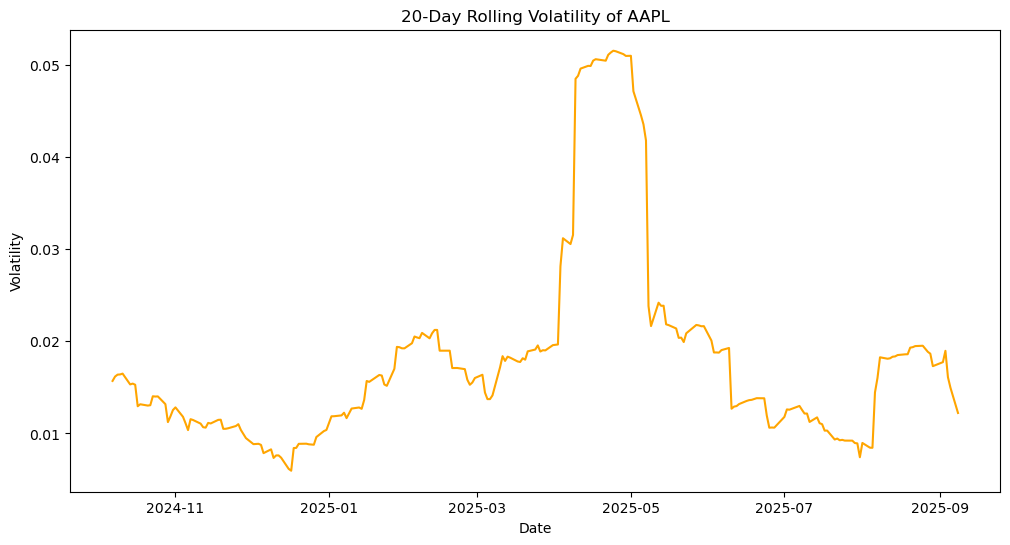

In [18]:
aapl_df['Rolling_volatility'] = aapl_df['Daily_return'].rolling(window=20).std()

plt.figure(figsize=(12,6))
plt.plot(aapl_df['Rolling_volatility'], color='orange')
plt.title('20-Day Rolling Volatility of AAPL')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.show()

*Findings:* This 20-day rolling volatility chart shows a few fluctuations in Apple's short-term risk levels throughout the year. There was a big spike in volatility around March 2025 to May 2025. This ties back in to the stock's significant closing price decline discussed earlier. Volatility gradually increased as the stock recovered. 

**Step 7**\
I will be doing some diagnostic analysis. I will be plotting 20 and 50-day moving averages to identify trends in Apple's stock.

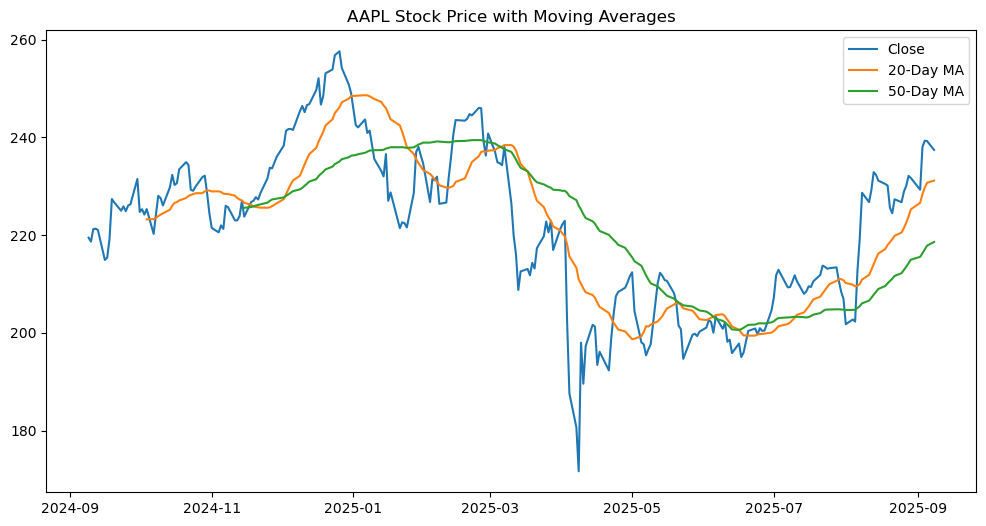

In [19]:
aapl_df['MA20'] = aapl_df['Close'].rolling(window=20).mean()
aapl_df['MA50'] = aapl_df['Close'].rolling(window=50).mean()

plt.figure(figsize=(12,6))
plt.plot(aapl_df['Close'], label='Close')
plt.plot(aapl_df['MA20'], label='20-Day MA')
plt.plot(aapl_df['MA50'], label='50-Day MA')
plt.title('AAPL Stock Price with Moving Averages')
plt.legend()
plt.show()

*Findings:* These moving averages give insight into Apple's short and medium term trends. When the 20-day MA (orange) crosses above the 50-day MA (green), it indicates a bullish (rising) movement, which is a potential signal for buying. When the 20-day MA drops below the 50-day MA, it suggests a bearish (falling) movement or a consolidation phase (moving sideways/plateau). There are a few crossovers on this chart, which means that Apple's stock price followed typical trends with upward movement and fall backs.

**Step 8**\
Now, I will be plotting the Distribution of Daily Returns. This will show how frequently Apple's stock experiences small or large price changes.

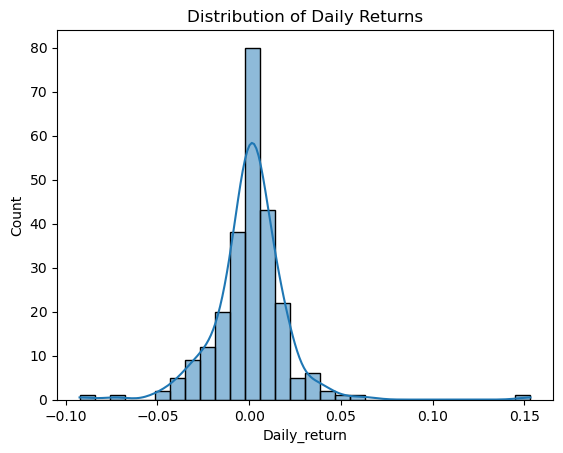

In [20]:
sns.histplot(aapl_df['Daily_return'].dropna(), bins=30, kde=True)
plt.title('Distribution of Daily Returns')
plt.show()

*Findings:* This histogram has a normal distribution shape with a minimal skew to the right, which indicates more small gains than losses. The histogram is centered around 0.0, meaning daily price changes were small, and gains/losses were mostly balanced. Some outliers (longer tails) suggest that there were some infrequent large price movements. Overall, this distribution shows Apple's relatively stable risk profile.

**Step 9**\
I will plot the average daily volatility for each weekday. This will allow me to analyze which days historically experience higher or lower risk.

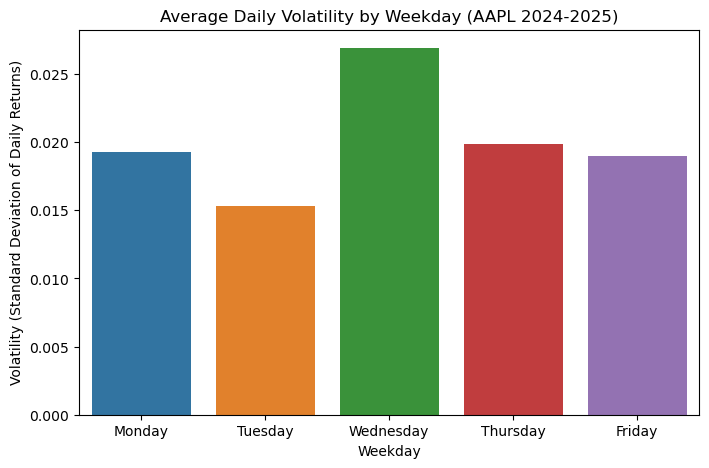

Weekday
Monday       0.019319
Tuesday      0.015341
Wednesday    0.026911
Thursday     0.019848
Friday       0.019020
Name: Daily_return, dtype: float64

In [21]:
aapl_df['Weekday'] = aapl_df.index.day_name()

weekday_vol = aapl_df.groupby('Weekday')['Daily_return'].std().reindex(
    ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
)

plt.figure(figsize=(8,5))
sns.barplot(x=weekday_vol.index, y=weekday_vol.values)
plt.title('Average Daily Volatility by Weekday (AAPL 2024-2025)')
plt.xlabel('Weekday')
plt.ylabel('Volatility (Standard Deviation of Daily Returns)')
plt.show()

weekday_vol

*Findings:* Apple's stock shows some fluctuations in volatility over the weekdays. Wednesday has the highest average volatility of 0.0269. This could suggest that mid-week trading involves larger price swings. That could be due to company announcements which may be happening mid-week. Tuesday seems like a more stable trading day, as it has the lowest volatility, 0.015341.
While volatility varies slightly by weekday, the variability is not huge. This pattern does support the hypothesis that stock volatility could exhibit trends, which could help investors be more informed and anticipate periods of higher or lower risk to better manage trades or strategies.


**Step 10**\
Finally, I will perform a one-sample t-test to determine if Apple's stock returns are statistically different from zero.

In [22]:
daily_returns = aapl_df['Daily_return'].dropna()

First, I had to create a variable "daily_returns" to ensure that there are no nan values. The t-test will not tolerate any nan values.

In [23]:
t_statistic, p_value = stats.ttest_1samp(daily_returns, popmean=0)
print('t_statistic:', t_statistic)
print('p_value:', p_value)

t_statistic: 0.4029300738852398
p_value: 0.6873467952648973


*Findings:* As we can see, the t-statistic is 0.40, and the p-value is 0.69, which is more than our alpha value of 0.05. This means that the null hypothesis is not rejected and there is no statistically significant evidence that Apple's average daily return differs from 0.

***Conclusion***\
The analysis of Apple's stock performance from September 2024 to September 2025 provides a clear view of it's price behavior and volatility trends. The findings address the research question: "How can the analysis of historical stock prices over the past year help investors understand short-term volatility patterns in a selected stock? "
Apple's stock generally trended upward over the year, with a large decline between March and May 2025. The stock slowly recovered from the decline, ending slightly higher than it began, demonstrating overall resilience. Daily return analysis showed that most price fluctuations were moderate, with occasional large movements, which indicates that short-term price changes are usually predictable, with a few outliers. The overall volatility of 0.0204 reflects moderate risk. The 20-day rolling volatility showed dynamic changes in risk, peaking during the decline and decreasing as the stock recovered. Moving averages (20 and 50 day) highlighted short-term and long-term trends.\
\
Weekday volatility analysis revealed small but informative differences: wednesday showed the highest average volatility (0.0269), and tuesday showed the lowest (0.0153), suggesting mid-week trading  tends to have larger price swings. These patterns sligthly support the hypothesis that volatility exhibits consistent trends, which can inform short-term investment strategies.\
\
A one-sample t-test was applied to Apple's daily returns to determine whether the average return differed significantly from zero. Thew test produced a t-statistic of 0.403 and a p-value of 0.687, which is greater than the alpha level of 0.05. As a result, the null hypothesis was not rejected, indicating that the average daily return was not statistically different from zero. While returns did not show statistical significance, volatility patterns clearly varied over time and provided risk insights.\
\
Overall, Apple's stock showed moderate, time-varying volatility with observable trends, confirming that monitoring historical stock behavior can provide actionable insights for investors. This analysis demonstrates how descriptive and diagnostic techniques, including daily returns, rolling volatility, moving averages, and weekday comparisons, can support data-driven decision making and risk management in short-term trading.